# Análisis Conjoint - Preferencias de Vuelos

## ¿Qué es el Análisis Conjoint?

**Qué es:** técnica que descompone la valoración global de un producto (rating 1-10) en la contribución de cada atributo/nivel que lo compone. En vez de preguntar directamente "¿cuánto te importa el precio?", se muestran productos completos (combinaciones de atributos) y se pide valorarlos o elegir entre ellos. El modelo estadístico infiere después cuánto vale cada característica por separado.

**Supuesto clave:** la utilidad total de un producto = suma de las utilidades parciales (*part-worths*) de cada uno de sus niveles.

**Mecanismo (es una regresión lineal):**
- **Target (y):** rating dado a cada combinación de producto.
- **Features (X):** atributos codificados como dummies (one-hot) — ej. Marca A/B/C, Precio bajo/medio/alto.
- **Coeficientes (β):** son las *part-worths* — cuánto suma o resta cada nivel a la valoración total.

$$y_{pred} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots$$

**Interpretación:** un coeficiente alto en "Marca Samsung" significa que esa marca por sí sola aporta mucho valor percibido. Sumando los coeficientes de todos los atributos de un producto (real o hipotético) se obtiene su utilidad total predicha — permite simular combinaciones nunca mostradas al cliente.

**Dos variantes:**
- **Rating-based Conjoint** (clásico): regresión lineal, como arriba.
- **Choice-Based Conjoint (CBC):** el cliente elige entre opciones en vez de puntuar → el modelo es logit multinomial, no regresión lineal.

**Uso empresarial:**
- Pricing: cuánto se puede subir el precio antes de que la pérdida de utilidad supere la ganancia de una feature nueva.
- Priorización de features en producto.
- Diseño de "producto óptimo" vía simulación de combinaciones.

### Atributos y niveles

Son los 5 componentes que se combinarán para formar los "productos" (perfiles de vuelo) que se le mostrarán al encuestado. Cada atributo tiene 2-3 niveles, y el diseño factorial combinará estos niveles en distintos perfiles de vuelo que la persona puntuará o entre los que elegirá. De ahí saldrán los part-worths: cuánto pesa cada nivel en la decisión final.

- **Precio**: el driver económico — 3 niveles permiten estimar si la relación precio-utilidad es lineal o no.
- **Equipaje**: atributo binario de servicio incluido/no incluido.
- **Selección de asiento**: binario — controlar dónde te sientas vs. asignación aleatoria.
- **Vuelo**: número de escalas — proxy de duración/comodidad del viaje.
- **Flexibilidad**: binario — poder cambiar/cancelar el billete o no.

-- 

| Atributo               | Niveles                              | Nº niveles |
|-------------------------|----------------------------------------|:---:|
| Precio                  | 50€ / 100€ / 150€                     | 3 |
| Equipaje                | 20 kg incluido / Sin equipaje         | 2 |
| Selección de asiento    | Con selección / Aleatoria             | 2 |
| Vuelo                   | Directo / 1 escala                    | 2 |
| Flexibilidad            | Con flexibilidad / Sin flexibilidad   | 2 |
| Horario                 | Mañana / Tarde / Noche                | 3 |

Con 6 atributos, el diseño factorial completo pasa a 3×2×2×2×2×3 = 144 combinaciones. Sigue reforzando por qué en el cuestionario real se usa un subconjunto ortogonal (fractional factorial), no las 144 enteras.

| Atributo               | Vuelo A               | Vuelo B                | Vuelo C                |
|-------------------------|------------------------|--------------------------|--------------------------|
| Precio                  | 50€                    | 100€                     | 150€                     |
| Equipaje                | 20 kg incluido          | Sin equipaje               | 20 kg incluido            |
| Selección de asiento    | Con selección           | Aleatoria                  | Aleatoria                  |
| Vuelo                   | Directo                 | 1 escala                   | Directo                    |
| Flexibilidad            | Sin flexibilidad        | Con flexibilidad           | Con flexibilidad           |
| Horario                 | Mañana                  | Tarde                      | Noche                      |
| **Rating (1-10)**       | ___                     | ___                         | ___                         |

In [77]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns

import statsmodels.formula.api as smf

In [78]:
# Estilo visual para todos los gráficos del notebook

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.05
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

RUTA_EXCEL = "Conjoint_Flight.xlsx"

COLOR_PRINCIPAL = "#2E5EAA"

PALETA_SEGMENTOS = {
    "Business": "#2E5EAA",
    "Leisure": "#E8A33D",
    "Low Cost": "#3EB489"
}

In [79]:
df = pd.read_excel(RUTA_EXCEL, sheet_name="Transacciones")

In [80]:
display(df)

,CustomerID,Segment,CardID,Price,Baggage,Seat,Flight,Flexible,Departure,Rating
0,1,Business,1,50,20 kg,Seat Selection,Direct,Yes,Morning,10.0
1,1,Business,2,50,No baggage,Random,Direct,No,Afternoon,8.6
2,1,Business,3,50,20 kg,Random,1 Stop,Yes,Evening,7.2
3,1,Business,4,50,No baggage,Seat Selection,1 Stop,No,Morning,7.4
4,1,Business,5,50,20 kg,Seat Selection,Direct,No,Evening,10.0
...,...,...,...,...,...,...,...,...,...,...
23995,1000,Leisure,20,100,No baggage,Seat Selection,Direct,Yes,Morning,9.0
23996,1000,Leisure,21,150,20 kg,Random,Direct,No,Evening,6.1
23997,1000,Leisure,22,50,No baggage,Seat Selection,1 Stop,Yes,Morning,6.9
23998,1000,Leisure,23,100,20 kg,Seat Selection,Direct,No,Afternoon,9.6


In [81]:
print(f"Clientes únicos: {df['CustomerID'].nunique()}")
print(f"Tarjetas (CardID) únicas {df['CardID'].nunique()}")
print(f"Filas esperadas (clientes x tarjetas): {df['CustomerID'].nunique() * df['CardID'].nunique():,}".replace(",", "."))
print("\nClientes por segmento:")

print(df.groupby("Segment")["CustomerID"].nunique())


Clientes únicos: 1000
Tarjetas (CardID) únicas 24
Filas esperadas (clientes x tarjetas): 24.000

Clientes por segmento:
Segment
Business    316
Leisure     499
Low Cost    185
Name: CustomerID, dtype: int64


# 2. El diseño experimental: las 24 tarjetas

En un conjoint clasico, no se prueban todas las combinaciones posibles (eso seria un diseño factorial completo), sino un subconjunto diseñado estadisticamente (diseño ortogonal) que permite estimar el efecto de cada atributo por separado. 

Aqui tenemos 6 atributos, cada uno con 2 o 3 

| Atributo               | Niveles                              | Nº niveles |
|-------------------------|----------------------------------------|:---:|
| Precio                  | 50€ / 100€ / 150€                     | 3 |
| Equipaje                | 20 kg incluido / Sin equipaje         | 2 |
| Selección de asiento    | Con selección / Aleatoria             | 2 |
| Vuelo                   | Directo / 1 escala                    | 2 |
| Flexibilidad            | Con flexibilidad / Sin flexibilidad   | 2 |
| Horario                 | Mañana / Tarde / Noche                | 3 |

Un diseño factorial completo tendría 3x2x2x2x2x3 = 216 combinaciones. El diseño ortogonal usado aquí las reduce a solo 24 tarjetas, manteniendo el equilibrio necesario apra estimar todos los efectos. 

In [82]:
# COMPROBACIÓN DEL DISEÑO CONJOINT

# Atributos que definen cada tarjeta
atributos = ["Price","Baggage","Seat","Flight","Flexible","Departure"]

# Seleccionamos el diseño del primer cliente
primer_cliente = df["CustomerID"].iloc[0]

diseno = (
    df[df["CustomerID"] == primer_cliente]
    [["CardID"] + atributos]
    .reset_index(drop=True)
)

# Seleccionamos el diseño de otro cliente para comparar
otro_id_cliente = df["CustomerID"].unique()[5]

otro_cliente = (
    df[df["CustomerID"] == otro_id_cliente]
    [["CardID"] + atributos]
    .reset_index(drop=True)
)

# Comprobamos si ambos clientes han evaluado exactamente
# el mismo diseño de tarjetas
mismo_diseno = diseno.equals(otro_cliente)

# Resultado
print(
    f"¿Todos los clientes evalúan el mismo diseño "
    f"de 24 tarjetas? -> {mismo_diseno}"
)

# Visualización del diseño
diseno.style.set_caption("Las 24 tarjetas del diseño conjoint")

¿Todos los clientes evalúan el mismo diseño de 24 tarjetas? -> True


,CardID,Price,Baggage,Seat,Flight,Flexible,Departure
0,1,50,20 kg,Seat Selection,Direct,Yes,Morning
1,2,50,No baggage,Random,Direct,No,Afternoon
2,3,50,20 kg,Random,1 Stop,Yes,Evening
3,4,50,No baggage,Seat Selection,1 Stop,No,Morning
4,5,50,20 kg,Seat Selection,Direct,No,Evening
5,6,50,No baggage,Random,1 Stop,Yes,Afternoon
6,7,100,20 kg,Random,Direct,Yes,Morning
7,8,100,No baggage,Seat Selection,Direct,No,Evening
8,9,100,20 kg,Seat Selection,1 Stop,No,Afternoon
9,10,100,No baggage,Random,1 Stop,Yes,Morning


# Análisis EDA


Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


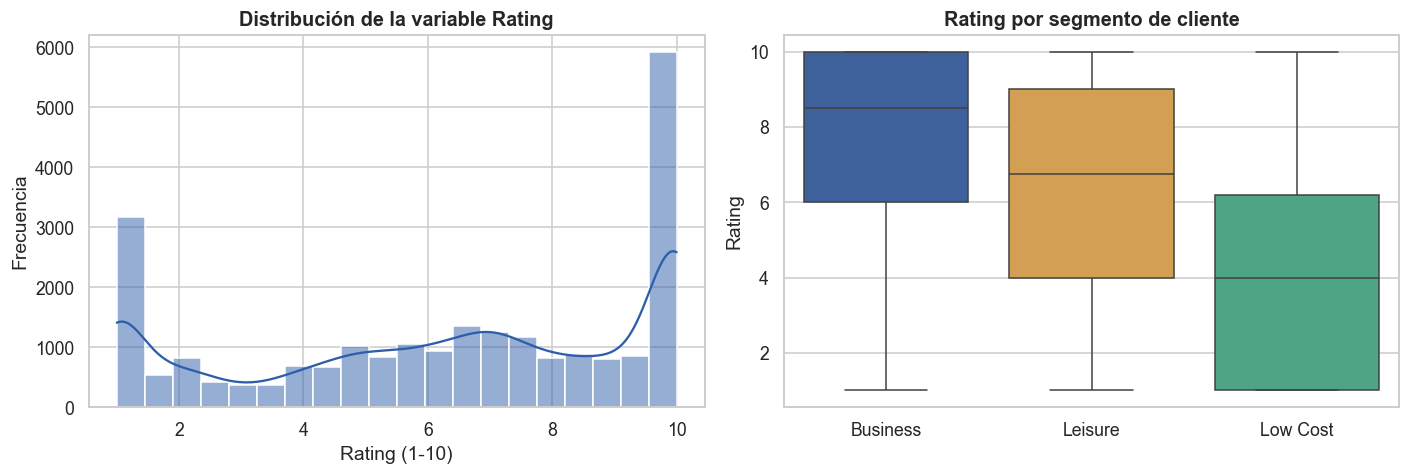

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    data=df,
    x="Rating",
    bins=20,
    color=COLOR_PRINCIPAL,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribución de la variable Rating")
axes[0].set_xlabel("Rating (1-10)")
axes[0].set_ylabel("Frecuencia")


sns.boxplot(
    data=df,
    x="Segment",
    y="Rating",
    ax=axes[1],
    palette=PALETA_SEGMENTOS,
    order=["Business", "Leisure", "Low Cost"]
)

axes[1].set_title("Rating por segmento de cliente")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.show()

In [84]:
df.head(10)

,CustomerID,Segment,CardID,Price,Baggage,Seat,Flight,Flexible,Departure,Rating
0,1,Business,1,50,20 kg,Seat Selection,Direct,Yes,Morning,10.0
1,1,Business,2,50,No baggage,Random,Direct,No,Afternoon,8.6
2,1,Business,3,50,20 kg,Random,1 Stop,Yes,Evening,7.2
3,1,Business,4,50,No baggage,Seat Selection,1 Stop,No,Morning,7.4
4,1,Business,5,50,20 kg,Seat Selection,Direct,No,Evening,10.0
5,1,Business,6,50,No baggage,Random,1 Stop,Yes,Afternoon,4.5
6,1,Business,7,100,20 kg,Random,Direct,Yes,Morning,10.0
7,1,Business,8,100,No baggage,Seat Selection,Direct,No,Evening,9.1
8,1,Business,9,100,20 kg,Seat Selection,1 Stop,No,Afternoon,7.5
9,1,Business,10,100,No baggage,Random,1 Stop,Yes,Morning,6.3


In [85]:
# Preparación de los datos
# Codificación DUMMY

df["Price"]     = pd.Categorical(df["Price"],     categories=[50,100,150])
df["Baggage"]   = pd.Categorical(df["Baggage"],   categories=["No baggage","20 kg"])
df["Seat"]      = pd.Categorical(df["Seat"],      categories=["Random", "Seat Selection"])
df["Flight"]    = pd.Categorical(df["Flight"],    categories=["1 Stop", "Direct"])
df["Flexible"]  = pd.Categorical(df["Flexible"],  categories=["No", "Yes"])
df["Departure"] = pd.Categorical(df["Departure"], categories=["Morning", "Afternoon", "Evening"])


In [86]:
#Estimación modelo conjoint (Regresion OLS)
formula = "Rating ~ C(Price) + C(Baggage) + C(Seat) + C(Flight) + C(Flexible) + C(Departure)"
modelo = smf.ols(formula, data=df).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     8877.
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:24:18   Log-Likelihood:                -45113.
No. Observations:               24000   AIC:                         9.024e+04
Df Residuals:                   23991   BIC:                         9.032e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [87]:
# Utilidades parciales (Part-worths)

orden = {
    "Price": ["50", "100", "150"],
    "Baggage": ["No baggage", "20 kg"],
    "Seat": ["Random", "Seat Selection"],
    "Flight": ["1 stop", "Direct"],
    "Flexible": ["No", "Yes"],
    "Departure": ["Morning", "Afternoon", "Evening"]
}


def extraer_partworths(modelo, atributos, orden):
    filas = []
    params = modelo.params

    for atributo in atributos:
        niveles = orden[atributo]

        # Nivel de referencia
        filas.append({
            "Atributo": atributo,
            "Nivel": str(niveles[0]),
            "Utilidad": 0.0
        })

        # Resto de niveles
        for nivel in niveles[1:]:
            clave = f"C({atributo})[T.{nivel}]"

            filas.append({
                "Atributo": atributo,
                "Nivel": str(nivel),
                "Utilidad": params[clave]
            })

    return pd.DataFrame(filas)


partworths = extraer_partworths(modelo, atributos, orden)

partworths

,Atributo,Nivel,Utilidad
0,Price,50,0.000000
1,Price,100,-1.344414
2,Price,150,-4.108242
3,Baggage,No baggage,0.000000
4,Baggage,20 kg,1.694892
5,Seat,Random,0.000000
6,Seat,Seat Selection,0.545708
7,Flight,1 stop,0.000000
8,Flight,Direct,3.051530
9,Flexible,No,0.000000


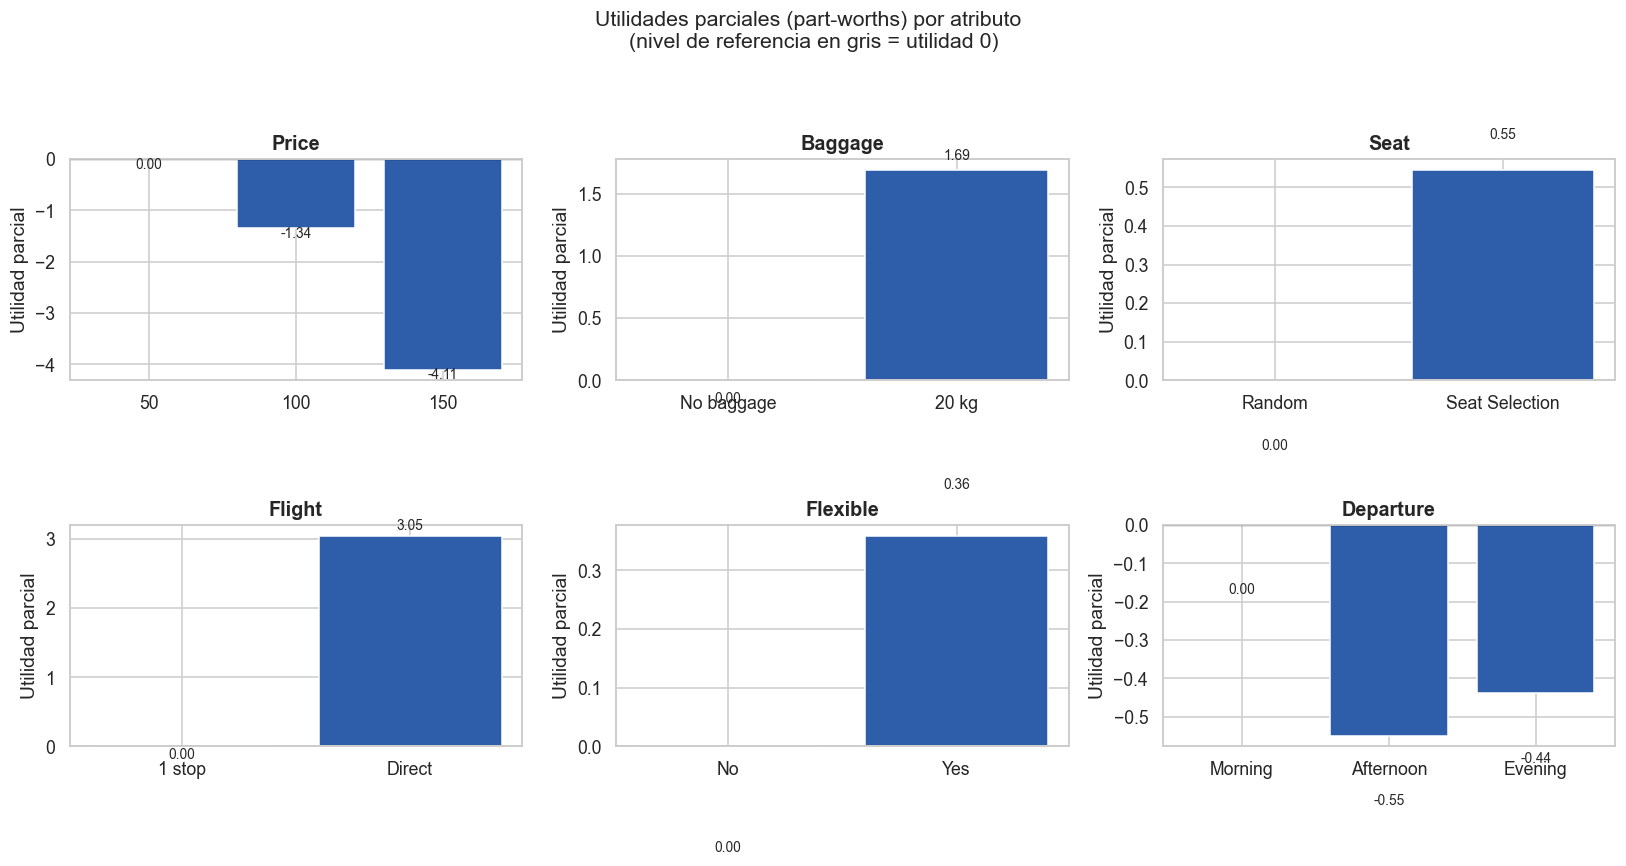

In [88]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for ax, atributo in zip(axes, atributos):
    sub = partworths[partworths["Atributo"] == atributo]
    colores = ["#B5B5B5" if u == 0 else COLOR_PRINCIPAL for u in sub["Utilidad"]]
    barras = ax.bar(sub["Nivel"], sub["Utilidad"], color = colores)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(atributo)
    ax.set_ylabel("Utilidad parcial")
    for barra, valor in zip(barras, sub["Utilidad"]):
        ax.text(barra.get_x() + barra.get_width()/2, valor + (0.08 if valor >0 else -0.18),
                f"{valor:.2f}", ha="center", fontsize=9)
plt.suptitle("Utilidades parciales (part-worths) por atributo \n (nivel de referencia en gris = utilidad 0)", 
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show() 

In [89]:
# Importancia relativa de los atributos

rangos = partworths.groupby("Atributo")["Utilidad"].agg(lambda x:x.max()-x.min())
importancia = (rangos/ rangos.sum()*100).sort_values(ascending=False)

tabla_importancia = importancia.reset_index()
tabla_importancia.columns = ["Atributo", "Importancia (%)"]

tabla_importancia

,Atributo,Importancia (%)
0,Price,39.849164
1,Flight,29.599263
2,Baggage,16.440129
3,Departure,5.334715
4,Seat,5.293260
5,Flexible,3.483469


In [90]:
#Importancia por segmentos

segmentos = ["Business", "Leisure", "Low Cost"]

resultados_segmento = {}
importancia_segmento = {}

for seg in segmentos:
    
    # Filtrar datos del segmento
    datos_seg = df[df["Segment"] == seg]
    
    # Ajustar modelo
    modelo_seg = smf.ols(formula, data=datos_seg).fit()
    
    # Extraer part-worths
    pw_seg = extraer_partworths(modelo_seg, atributos, orden)
    resultados_segmento[seg] = pw_seg
    
    # Calcular rango de utilidad por atributo
    rangos_seg = (
        pw_seg
        .groupby("Atributo")["Utilidad"]
        .agg(lambda x: x.max() - x.min())
    )
    
    # Calcular importancia relativa (%)
    importancia_segmento[seg] = (
        rangos_seg / rangos_seg.sum() * 100
    )

# Crear tabla comparativa
importancia_comparada = (
    pd.DataFrame(importancia_segmento)
    .reindex(atributos)
)

# Mostrar resultados
importancia_comparada

,Business,Leisure,Low Cost
Atributo,,,
Price,24.409257,39.623530,59.650226
Baggage,14.558816,17.769133,13.170350
Seat,8.406153,5.999746,2.588005
Flight,37.899458,26.730385,20.318204
Flexible,5.022132,4.310204,1.944357
Departure,9.704183,5.567002,2.328857
